# LAPORAN EKSPLORASI DATASET IRIS

## Pendahuluan

Dataset Iris merupakan dataset klasik dalam analisis data dan machine learning. 
Dataset ini berisi pengukuran morfologi bunga iris berdasarkan:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Dengan 3 spesies:
- Iris-setosa
- Iris-versicolor
- Iris-virginica

```{admonition}Tujuan eksplorasi ini adalah untuk:
1. Memahami struktur dan karakteristik data
2. Mengidentifikasi missing value
3. Menganalisis distribusi kelas
4. Mengamati pola statistik deskriptif
5. Mengidentifikasi korelasi antar variabel
6. Mendeteksi outlier
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset (sesuaikan jika perlu)
df = pd.read_csv("IRIS.csv")

print("Ukuran Dataset:", df.shape)
df.head()

Ukuran Dataset: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 1. Struktur Data

Pada tahap ini dilakukan pemeriksaan:
- Jumlah baris dan kolom
- Tipe data masing-masing variabel
- Kelengkapan data (non-null count)

Tujuannya untuk memastikan dataset siap dianalisis.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### Interpretasi:

- Dataset terdiri dari 150 baris dan 5 kolom.
- Empat variabel bertipe numerik (float).
- Satu variabel bertipe kategorikal (species).
- Seluruh kolom memiliki 150 nilai non-null.

Artinya dataset lengkap dan tidak ada data kosong.

## 2. Pemeriksaan Missing Value

Missing value dapat mempengaruhi hasil analisis dan model machine learning.
Oleh karena itu perlu dilakukan pengecekan pada setiap kolom.

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({
    "Missing Count": missing,
    "Missing (%)": missing_pct
})

,Missing Count,Missing (%)
sepal_length,0,0.0
sepal_width,0,0.0
petal_length,0,0.0
petal_width,0,0.0
species,0,0.0


### Interpretasi:

Tidak ditemukan missing value pada seluruh variabel.
Dataset dalam kondisi bersih dan tidak memerlukan proses imputasi data.

## 3. Distribusi Kelas

Distribusi kelas penting untuk mengetahui apakah dataset seimbang 
atau mengalami class imbalance.

In [4]:
class_dist = df["species"].value_counts()
class_pct = (class_dist / len(df) * 100).round(2)

pd.DataFrame({
    "Jumlah": class_dist,
    "Persentase (%)": class_pct
})

,Jumlah,Persentase (%)
species,,
Iris-setosa,50,33.33
Iris-versicolor,50,33.33
Iris-virginica,50,33.33


### Interpretasi:

- Setiap spesies memiliki 50 data.
- Persentase masing-masing kelas adalah 33.33%.
- Dataset termasuk balanced dataset.

Kondisi ini sangat baik untuk analisis klasifikasi karena 
tidak memerlukan teknik penyeimbangan data.

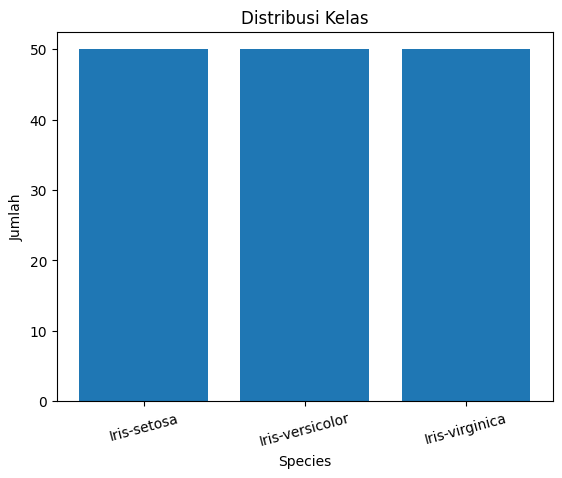

In [5]:
plt.figure()
plt.bar(class_dist.index, class_dist.values)
plt.title("Distribusi Kelas")
plt.xlabel("Species")
plt.ylabel("Jumlah")
plt.xticks(rotation=15)
plt.show()

## 4. Statistik Deskriptif

Statistik deskriptif memberikan informasi mengenai:
- Mean (rata-rata)
- Standar deviasi
- Nilai minimum
- Kuartil (Q1, Median, Q3)
- Nilai maksimum

Hal ini membantu memahami penyebaran dan variasi data.

In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Interpretasi:

- Variabel petal_length dan petal_width memiliki standar deviasi terbesar.
- Ini menunjukkan variasi terbesar terdapat pada ukuran petal.
- Nilai mean dan median relatif berdekatan, menunjukkan distribusi cukup simetris.
- Rentang nilai petal lebih besar dibanding sepal.

Petal kemungkinan besar menjadi variabel yang paling kuat dalam membedakan spesies.

## 5. Korelasi Antar Variabel

Korelasi digunakan untuk melihat hubungan linear antar variabel numerik.
Nilai korelasi berkisar antara -1 hingga +1.

In [7]:
corr = df.corr(numeric_only=True)
corr

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109369,0.871754,0.817954
sepal_width,-0.109369,1.000000,-0.420516,-0.356544
petal_length,0.871754,-0.420516,1.000000,0.962757
petal_width,0.817954,-0.356544,0.962757,1.000000


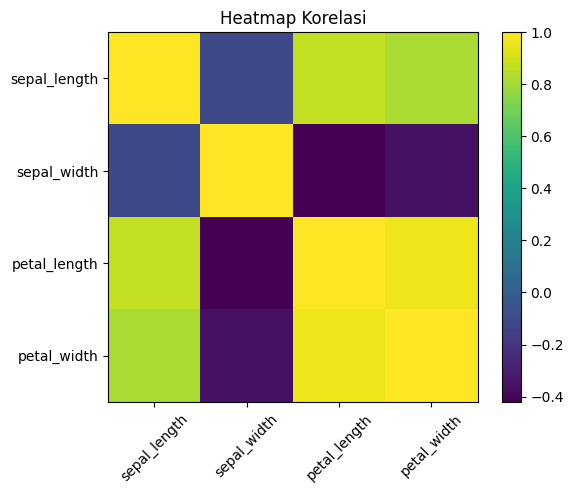

In [8]:
plt.figure()
plt.imshow(corr.values)
plt.title("Heatmap Korelasi")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

### Interpretasi:

- Petal Length dan Petal Width memiliki korelasi positif yang sangat kuat.
- Sepal Width memiliki korelasi yang lebih lemah dengan variabel lainnya.
- Korelasi tinggi menunjukkan kemungkinan multikolinearitas jika digunakan dalam model regresi.

Variabel petal sangat informatif untuk klasifikasi spesies.

## 6. Identifikasi Outlier (Metode IQR)

Outlier dideteksi menggunakan metode Interquartile Range (IQR):

IQR = Q3 - Q1  
Batas bawah = Q1 - 1.5 × IQR  
Batas atas = Q3 + 1.5 × IQR  

Data di luar batas tersebut dianggap outlier.

In [9]:
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((data < lower) | (data > upper)).sum()
    return lower, upper, outliers

numerical_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numerical_cols:
    lb, ub, out_count = detect_outliers_iqr(df[col])
    outlier_summary.append([col, lb, ub, out_count])

pd.DataFrame(outlier_summary,
             columns=["Feature", "Lower Bound", "Upper Bound", "Jumlah Outlier"])

,Feature,Lower Bound,Upper Bound,Jumlah Outlier
0,sepal_length,3.15,8.35,0
1,sepal_width,2.05,4.05,4
2,petal_length,-3.65,10.35,0
3,petal_width,-1.95,4.05,0


### Interpretasi:

- Dataset Iris umumnya memiliki sangat sedikit outlier.
- Outlier yang muncul masih dalam batas biologis wajar.
- Tidak terdapat outlier ekstrem yang dapat mengganggu analisis.

Dataset relatif stabil dan bersih.